In [32]:
import pandas as pd

train_1 = pd.read_csv('train_1.csv', index_col=0)
train_2 = pd.read_csv('train_2.csv', index_col=0)

train = pd.concat([train_1, train_2], ignore_index=True)

print(train.shape)


(614, 12)


In [33]:
print(train.dtypes)
print(train.isnull().sum())

train = train.dropna(thresh=train.shape[1] * 0.05)
print(train.isnull().sum())
print(train.shape)


Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
(614, 12)


1.2 Answer: There are still 614 records even after dropping.

In [34]:
train['Gender'] = train['Gender'].fillna(train['Gender'].value_counts().idxmax())
train['Married'] = train['Married'].fillna(train['Married'].value_counts().idxmax())
train['Dependents'] = train['Dependents'].fillna(train['Dependents'].value_counts().idxmax())
train['Self_Employed'] = train['Self_Employed'].fillna(train['Self_Employed'].value_counts().idxmax())
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].mode()[0])
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
train['Credit_History'] = train['Credit_History'].fillna(train['Credit_History'].mode()[0])

print(train.isnull().sum())


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [35]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

le = LabelEncoder()
train['Gender'] = le.fit_transform(train['Gender'])
train['Married'] = le.fit_transform(train['Married'])
train['Dependents'] = le.fit_transform(train['Dependents'])
train['Education'] = le.fit_transform(train['Education'])
train['Self_Employed'] = le.fit_transform(train['Self_Employed'])
train['Property_Area'] = le.fit_transform(train['Property_Area'])
train['Loan_Status'] = le.fit_transform(train['Loan_Status'])

print(train.dtypes)

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


Correlation between ApplicantIncome and LoanAmount: 0.5646981704353977


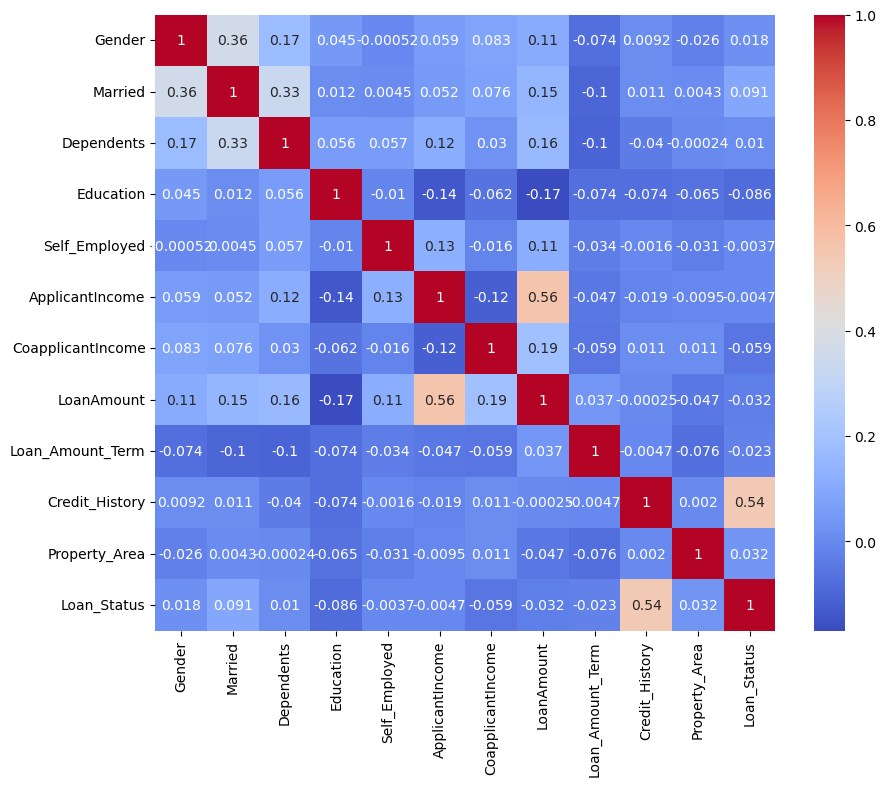

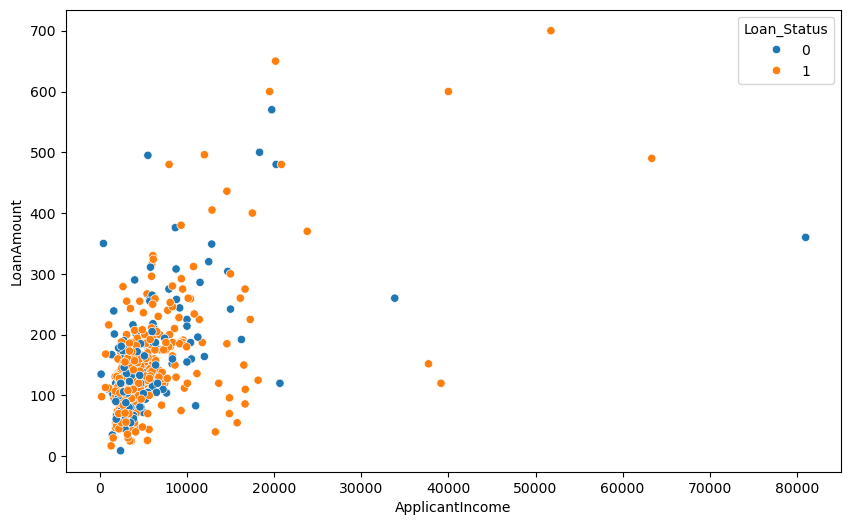

In [36]:
correlation = train['ApplicantIncome'].corr(train['LoanAmount'])
print(f"Correlation between ApplicantIncome and LoanAmount: {correlation}")

plt.figure(figsize=(10, 8))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=train)
plt.show()


Intercept: 103.41937200523812, Slope: 0.007781390371466644


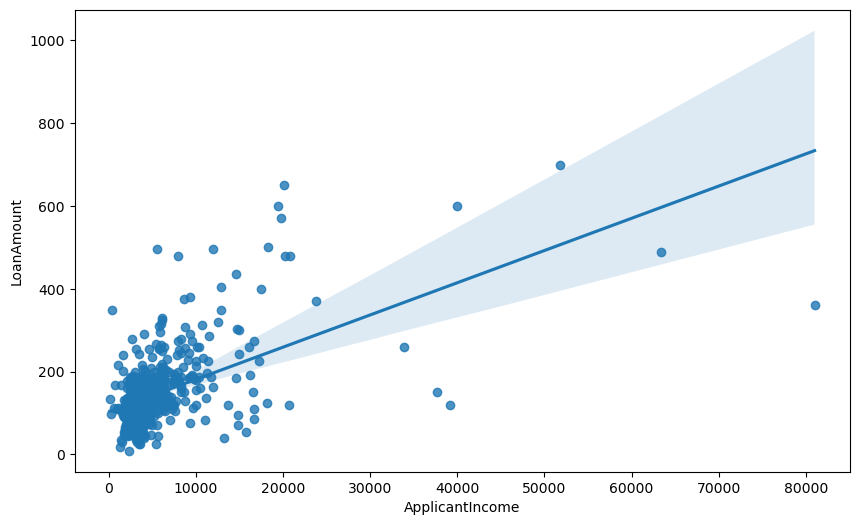

In [37]:
from statsmodels.formula.api import ols

model_formula = 'LoanAmount ~ ApplicantIncome'
model = ols(model_formula, data=train).fit()
print(f"Intercept: {model.params['Intercept']}, Slope: {model.params['ApplicantIncome']}")

plt.figure(figsize=(10, 6))
sns.regplot(x='ApplicantIncome', y='LoanAmount', data=train)
plt.show()